In [ ]:
import pandas as pd
import numpy as np

In [11]:
path = r"C:\Users\UI450907\Desktop\TE RWEST\Tesis\Results _IEEE39\Small Signal\Small Signal.xlsx"

dfs = pd.read_excel(path,sheet_name = None)


In [75]:
import pandas as pd

# Dominant pole data extracted from PowerFactory
data = {
    "Case": ["R00","R01","R02","R03","R04","R05","R06","R07"],
    "PV_penetration_pct": [0.0,4.0,13.0,21.5,30.0,40.0,51.1,61.7],
    "Mode": [
        "Mode 00005",
        "Mode 00017",
        "Mode 00021",
        "Mode 00019",
        "Mode 00033",
        "Mode 00027",
        "Mode 00031",
        "Unstable pole"
    ],
    "sigma_real": [-0.197,-0.384,-0.384,-0.382,-0.461,-0.381,-0.407,59.464],
    "omega_imag": [6.975,6.613,6.739,6.735,7.550,6.244,6.535,0.0],
    "frequency_Hz": [1.110,1.052,1.072,1.072,1.202,0.994,1.040,0.0],
    "damping_pct": [2.82,5.80,5.69,5.67,6.10,6.10,6.22,None]
}

df = pd.DataFrame(data)

print(df)

  Case  PV_penetration_pct           Mode  sigma_real  omega_imag  \
0  R00                 0.0     Mode 00005      -0.197       6.975   
1  R01                 4.0     Mode 00017      -0.384       6.613   
2  R02                13.0     Mode 00021      -0.384       6.739   
3  R03                21.5     Mode 00019      -0.382       6.735   
4  R04                30.0     Mode 00033      -0.461       7.550   
5  R05                40.0     Mode 00027      -0.381       6.244   
6  R06                51.1     Mode 00031      -0.407       6.535   
7  R07                61.7  Unstable pole      59.464       0.000   

   frequency_Hz  damping_pct  
0         1.110         2.82  
1         1.052         5.80  
2         1.072         5.69  
3         1.072         5.67  
4         1.202         6.10  
5         0.994         6.10  
6         1.040         6.22  
7         0.000          NaN  


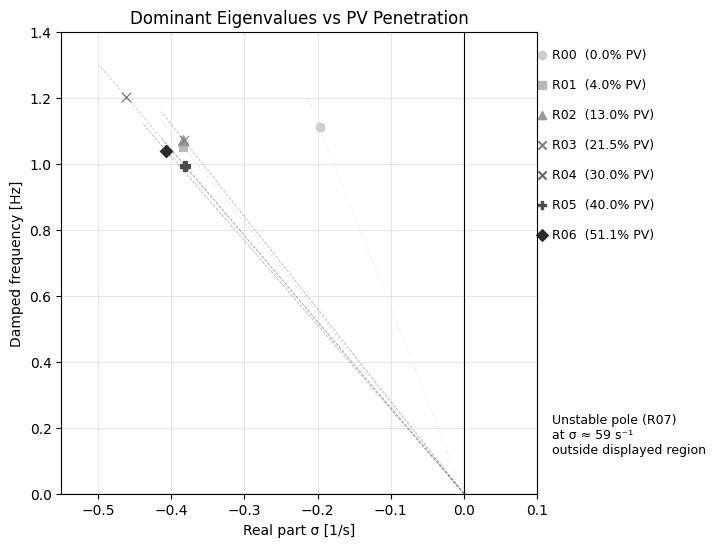

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- data assumed in df ---
# columns:
# Case, PV_penetration_pct, sigma_real, frequency_Hz

plt.figure(figsize=(8,6))

xlim = (-0.55, 0.1)
ylim = (0, 1.4)

ax = plt.gca()

# axes
plt.axvline(0, color="black", linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.8)

# grayscale colors with higher contrast
colors = plt.cm.Greys(np.linspace(0.3, 0.95, len(df)))

# markers per case
markers = ['o','s','^','x','x','P','D','>']

# marker sizes
sizes = [40,40,55,40,45,45,40,40]

legend_entries = []

for i, (_, row) in enumerate(df.iterrows()):

    x = row["sigma_real"]
    y = row["frequency_Hz"]
    case = row["Case"]
    pv = row["PV_penetration_pct"]

    if not (xlim[0] <= x <= xlim[1] and ylim[0] <= y <= ylim[1]):
        continue

    c = colors[i]
    marker = markers[i % len(markers)]
    size = sizes[i % len(sizes)]

    # eigenvalue marker
    plt.scatter(
        x, y,
        s=size,
        facecolor=c,
        marker=marker,
        linewidths=0.8,
        zorder=3
    )

    # ray from origin
    r = np.sqrt(x**2 + y**2)

    if r > 0:
        ext = 1.08
        x_ext = x * ext
        y_ext = y * ext

        plt.plot(
            [0, x_ext],
            [0, y_ext],
            linestyle="--",
            linewidth=0.6,
            color=c,
            alpha=0.35,
            zorder=2
        )

    legend_entries.append((case, pv, marker, c))

# limits
plt.xlim(xlim)
plt.ylim(ylim)

plt.xlabel("Real part σ [1/s]")
plt.ylabel("Damped frequency [Hz]")
plt.title("Dominant Eigenvalues vs PV Penetration")

plt.grid(True, alpha=0.3)

# space for legend
plt.subplots_adjust(right=0.72)

# legend text
x_text = 1.03
y0 = 0.95
dy = 0.065

for k, (case, pv, marker, c) in enumerate(legend_entries):

    y_pos = y0 - k*dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        f"{case}  ({pv:.1f}% PV)",
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

# unstable pole note
ax.text(
    1.03,
    0.08,
    "Unstable pole (R07)\nat σ ≈ 59 s⁻¹\noutside displayed region",
    transform=ax.transAxes,
    fontsize=9,
    va="bottom"
)

plt.show()

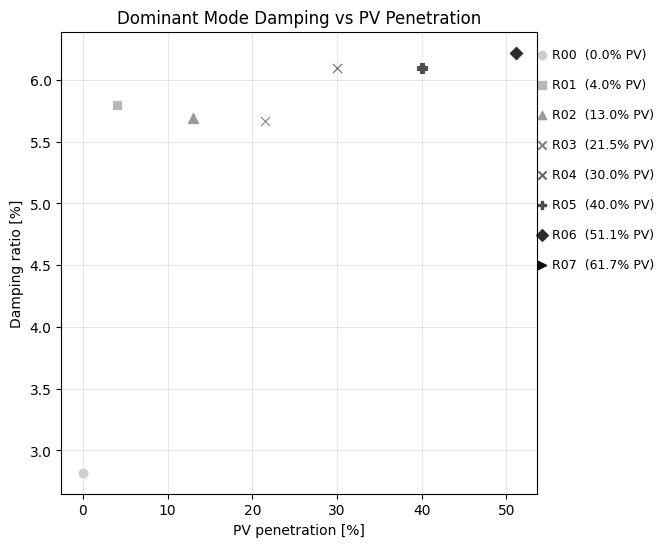

In [73]:
plt.figure(figsize=(8,6))

ax = plt.gca()

colors = plt.cm.Greys(np.linspace(0.3, 0.95, len(df)))
markers = ['o','s','^','x','x','P','D','>']
sizes = [40,40,55,40,45,45,40,40]

legend_entries = []

for i, (_, row) in enumerate(df.iterrows()):

    x = row["PV_penetration_pct"]
    y = row["damping_pct"]

    if y is None:
        continue

    case = row["Case"]
    pv = row["PV_penetration_pct"]

    c = colors[i]
    marker = markers[i % len(markers)]
    size = sizes[i % len(sizes)]

    plt.scatter(
        x,
        y,
        s=size,
        facecolor=c,
        marker=marker,
        linewidths=0.8,
        zorder=3
    )

    legend_entries.append((case, pv, marker, c))

plt.xlabel("PV penetration [%]")
plt.ylabel("Damping ratio [%]")
plt.title("Dominant Mode Damping vs PV Penetration")

plt.grid(True, alpha=0.3)

plt.subplots_adjust(right=0.72)

x_text = 1.03
y0 = 0.95
dy = 0.065

for k, (case, pv, marker, c) in enumerate(legend_entries):

    y_pos = y0 - k*dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        f"{case}  ({pv:.1f}% PV)",
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

plt.show()

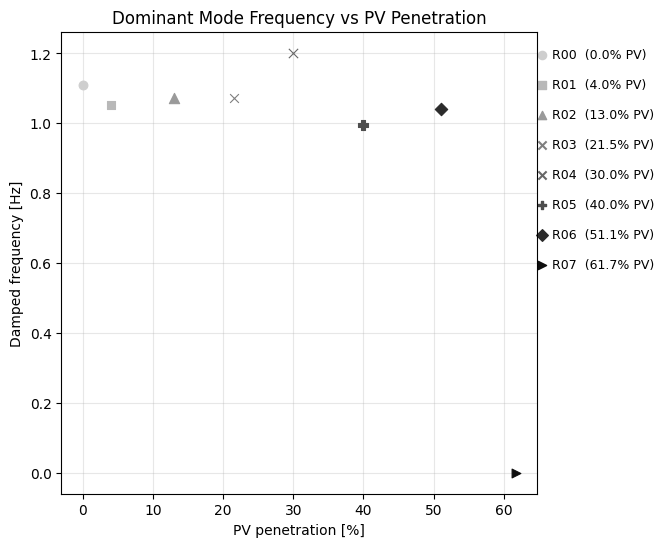

In [76]:
plt.figure(figsize=(8,6))

ax = plt.gca()

colors = plt.cm.Greys(np.linspace(0.3, 0.95, len(df)))
markers = ['o','s','^','x','x','P','D','>']
sizes = [40,40,55,40,45,45,40,40]

legend_entries = []

for i, (_, row) in enumerate(df.iterrows()):

    x = row["PV_penetration_pct"]
    y = row["frequency_Hz"]

    case = row["Case"]
    pv = row["PV_penetration_pct"]

    c = colors[i]
    marker = markers[i % len(markers)]
    size = sizes[i % len(sizes)]

    plt.scatter(
        x,
        y,
        s=size,
        facecolor=c,
        marker=marker,
        linewidths=0.8,
        zorder=3
    )

    legend_entries.append((case, pv, marker, c))

plt.xlabel("PV penetration [%]")
plt.ylabel("Damped frequency [Hz]")
plt.title("Dominant Mode Frequency vs PV Penetration")

plt.grid(True, alpha=0.3)

plt.subplots_adjust(right=0.72)

x_text = 1.03
y0 = 0.95
dy = 0.065

for k, (case, pv, marker, c) in enumerate(legend_entries):

    y_pos = y0 - k*dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        f"{case}  ({pv:.1f}% PV)",
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

plt.show()